In [2]:
import pandas as pd

In [3]:
file = pd.read_csv("../data/raw/openaccess/MetObjects.csv")
file.shape

C:\Users\Sahil\AppData\Local\Temp\ipykernel_26264\3336156477.py:1: DtypeWarning: Columns (5: Gallery Number, 7: AccessionYear, 10: Culture, 11: Period, 12: Dynasty, 13: Reign, 14: Portfolio, 34: Geography Type, 35: City, 36: State, 37: County, 38: Country, 39: Region, 40: Subregion, 41: Locale, 42: Locus, 43: Excavation, 44: River, 45: Classification, 46: Rights and Reproduction) have mixed types. Specify dtype option on import or set low_memory=False.
  file = pd.read_csv("../data/raw/openaccess/MetObjects.csv")


(484956, 54)

In [4]:
file.head()

,Object Number,Is Highlight,Is Timeline Work,Is Public Domain,Object ID,Gallery Number,Department,AccessionYear,Object Name,Title,...,River,Classification,Rights and Reproduction,Link Resource,Object Wikidata URL,Metadata Date,Repository,Tags,Tags AAT URL,Tags Wikidata URL
0,1979.486.1,False,False,False,1,NaN,The American Wing,1979.0,Coin,One-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/1,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
1,1980.264.5,False,False,False,2,NaN,The American Wing,1980.0,Coin,Ten-dollar Liberty Head Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/2,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
2,67.265.9,False,False,False,3,NaN,The American Wing,1967.0,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/3,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
3,67.265.10,False,False,False,4,NaN,The American Wing,1967.0,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/4,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN
4,67.265.11,False,False,False,5,NaN,The American Wing,1967.0,Coin,Two-and-a-Half Dollar Coin,...,NaN,NaN,NaN,http://www.metmuseum.org/art/collection/search/5,NaN,NaN,"Metropolitan Museum of Art, New York, NY",NaN,NaN,NaN


In [5]:
file.info()

<class 'pandas.DataFrame'>
RangeIndex: 484956 entries, 0 to 484955
Data columns (total 54 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Object Number            484956 non-null  str    
 1   Is Highlight             484956 non-null  bool   
 2   Is Timeline Work         484956 non-null  bool   
 3   Is Public Domain         484956 non-null  bool   
 4   Object ID                484956 non-null  int64  
 5   Gallery Number           49541 non-null   object 
 6   Department               484956 non-null  str    
 7   AccessionYear            481094 non-null  object 
 8   Object Name              482690 non-null  str    
 9   Title                    456153 non-null  str    
 10  Culture                  208190 non-null  str    
 11  Period                   91143 non-null   object 
 12  Dynasty                  23201 non-null   str    
 13  Reign                    11236 non-null   str    
 14  Portfolio      

In [8]:
to_keep = file.loc[(file["Department"].isin(["Asian Art", "European Paintings"])) & (file["Is Public Domain"] == True)]
to_keep.shape

(33622, 54)

In [10]:
cols_to_keep = ["Object ID", "Title", "Artist Display Name", "Object Date", "Medium", "Culture", "Credit Line", "Department"]

candidate_df = to_keep[cols_to_keep]
candidate_df.head()

,Object ID,Title,Artist Display Name,Object Date,Medium,Culture,Credit Line,Department
30295,35966,NaN,NaN,18th–19th century,Leather,Japan,"Gift of Mr. and Mrs. H. O. Havemeyer, 1896",Asian Art
30296,35967,NaN,NaN,18th century or earlier,Paint; on leather,China,"Gift of Mr. and Mrs. H. O. Havemeyer, 1896",Asian Art
30297,35968,清 佚名 台南地區荷蘭城堡|Forts Zeelandia and Provintia ...,Unidentified artist,19th century,Wall hanging; ink and color on deerskin,China,"Gift of J. Pierpont Morgan, 1909",Asian Art
30299,35970,明 丁雲鵬 潯陽送客圖 軸|Song of the Lute,Ding Yunpeng,1585,Hanging scroll; ink and color on paper,China,"John Stewart Kennedy Fund, 1913",Asian Art
30300,35971,清 佚名 倣王翬 倣李成山水圖 軸|Landscape after Li C...,Wang Hui|Unidentified artist,"18th century or later, spurious date of 1680",Hanging scroll; ink on silk,China,"John Stewart Kennedy Fund, 1913",Asian Art


In [11]:
candidate_df["Culture"].unique()

<StringArray>
[                                          'Japan',
                                           'China',
                                           'Korea',
                                     'North China',
 'China (Xinjiang Autonomous Region, Turfan area)',
                                  'China or Japan',
                               'India, Tamil Nadu',
                                        'Thailand',
           'Pakistan (ancient region of Gandhara)',
                                           'India',
 ...
               'North Central Thailand, Sukhothai',
                      'Vietnam, Hong River region',
                       'Myanmar (Burma), Mandalay',
                          'South India, Karnataka',
                  'Kashmir style in Western Tibet',
                      'India, Madurai, Tamil Nadu',
              'India, Kolkata (formerly Calcutta)',
           'South India, Andhra Pradesh, Tirupati',
                           'Eastern India, Od

In [13]:
import sys
sys.path.insert(0, "../src")  # adjust relative path as needed

from met_api import get_object
get_object(35966)

{'status_code': 200,
 'data': {'objectID': 35966,
  'isHighlight': False,
  'accessionNumber': '96.14.193',
  'accessionYear': '1896',
  'isPublicDomain': True,
  'primaryImage': 'https://images.metmuseum.org/CRDImages/as/original/DP11408.jpg',
  'primaryImageSmall': 'https://images.metmuseum.org/CRDImages/as/web-large/DP11408.jpg',
  'additionalImages': [],
  'constituents': None,
  'department': 'Asian Art',
  'objectName': 'Piece',
  'title': 'Piece',
  'culture': 'Japan',
  'period': 'Edo period (1615–1868)',
  'dynasty': '',
  'reign': '',
  'portfolio': '',
  'artistRole': '',
  'artistPrefix': '',
  'artistDisplayName': '',
  'artistDisplayBio': '',
  'artistSuffix': '',
  'artistAlphaSort': '',
  'artistNationality': '',
  'artistBeginDate': '',
  'artistEndDate': '',
  'artistGender': '',
  'artistWikidata_URL': '',
  'artistULAN_URL': '',
  'objectDate': '18th–19th century',
  'objectBeginDate': 1700,
  'objectEndDate': 1899,
  'medium': 'Leather',
  'dimensions': '8 1/10 x 3

In [14]:
candidate_df.to_csv("../data/processed/candidates.csv", index=False)

In [1]:
import sys
sys.path.append("..")

import pandas as pd
from src.dossier import build_dossier, UnusableRecordError

candidates = pd.read_csv("../data/processed/candidates.csv")
sample_ids = candidates["Object ID"].head(5).tolist()

for oid in sample_ids:
    try:
        print(build_dossier(oid))
    except UnusableRecordError as e:
        print(f"Skipped: {e}")

object_id=35966 title='Piece' artist=None date='18th–19th century' medium='Leather' department='Asian Art' credit_line='Gift of Mr. and Mrs. H. O. Havemeyer, 1896' image_url='https://images.metmuseum.org/CRDImages/as/original/DP11408.jpg' is_public_domain=True
object_id=35967 title='Panel' artist=None date='18th century or earlier' medium='Paint; on leather' department='Asian Art' credit_line='Gift of Mr. and Mrs. H. O. Havemeyer, 1896' image_url='https://images.metmuseum.org/CRDImages/as/original/DP11577.jpg' is_public_domain=True
object_id=35968 title='Forts Zeelandia and Provintia and the City of Tainan' artist='Unidentified artist' date='19th century' medium='Wall hanging; ink and color on deerskin' department='Asian Art' credit_line='Gift of J. Pierpont Morgan, 1909' image_url='https://images.metmuseum.org/CRDImages/as/original/DP354272.jpg' is_public_domain=True
object_id=35970 title='Song of the Lute' artist='Ding Yunpeng' date='1585' medium='Hanging scroll; ink and color on pap

In [2]:
import sys
sys.path.append("..")

from dotenv import load_dotenv
load_dotenv()

from src.workflow import dossier_graph

import logging
logging.getLogger("langsmith").setLevel(logging.WARNING)


for oid in sample_ids:
    result = dossier_graph.invoke({"object_id": oid, "raw_data": None, "error": None, "dossier": None})
    a = result["assessment"]
    print(oid, a.flag, a.confidence, "-", a.reason)

Object 35966: routing -> clean
35966 False High - No conflicting dates, the department (Asian Art) is appropriate for the medium (Leather), and leather existed during the 18th-19th centuries.
Object 35967: routing -> clean
35967 False high - 
Object 35968: routing -> clean
35968 False high - 
Object 35970: routing -> clean
35970 False high - 
Object 35971: routing -> flagged
35971 True high - The record states a date of '18th century or later' and a 'spurious date of 1680', which are conflicting dates.


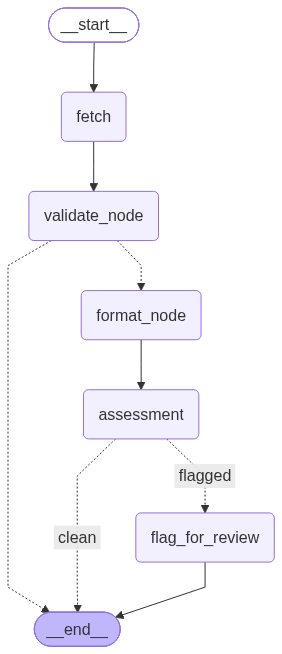

In [2]:
from dotenv import load_dotenv

import sys
sys.path.append("..")
load_dotenv()

from src.workflow import dossier_graph

dossier_graph

In [4]:
from langsmith import Client

client = Client()
print(client.info)

version='0.17.28' license_expiration_time=None batch_ingest_config={'use_multipart_endpoint': True, 'scale_up_qsize_trigger': 1000, 'scale_up_nthreads_limit': 16, 'scale_down_nempty_trigger': 4, 'size_limit': 100, 'size_limit_bytes': 20971520} instance_flags={'blob_storage_enabled': True, 'blob_storage_engine': 'gcs', 'ch_ingestion_enabled': True, 'ch_query_enabled': True, 'code_evaluator_advanced_configuration_supported': True, 'custom_apps_prepared_snapshot_supported': True, 'custom_apps_service_sandboxes_supported': True, 'custom_apps_skip_feature_flag': False, 'data_plane_allowed_regions': ['us-east-1', 'us-east-2', 'us-west-1', 'us-west-2'], 'dataset_examples_multipart_enabled': True, 'deprecated_api_usage_supported': True, 'developer_upgrade_tier': 'developer_07_2026', 'examples_multipart_enabled': True, 'fleet_feature_enabled': False, 'fleet_inline_agent_generation_enabled': False, 'fleet_thread_sandbox_provisioning_supported': True, 'free_tier': 'free_07_2026', 'generate_ai_que

In [5]:
import logging
logging.getLogger("langsmith").setLevel(logging.DEBUG)
logging.basicConfig()

In [8]:
import logging
logging.getLogger("langsmith").setLevel(logging.DEBUG)
logging.basicConfig()

from src.workflow import dossier_graph

for oid in sample_ids:
    result = dossier_graph.invoke({"object_id": oid, "raw_data": None, "error": None, "dossier": None})
    print(result)

DEBUG:langsmith.client:Compressed frame committed to ['https://apac.api.smith.langchain.com']
DEBUG:langsmith.client:Sending compressed multipart request with context: trace=01a0d18c-bbf2-7f53-9fe0-ae569a9ab72b,id=01a0d18c-bbf2-7f53-9fe0-ae569a9ab72b; trace=01a0d18c-bbf2-7f53-9fe0-ae569a9ab72b,id=01a0d18c-bbf7-7630-bad6-3e79bae92661
DEBUG:langsmith.client:Compressed frame committed to ['https://apac.api.smith.langchain.com']
DEBUG:langsmith.client:Sending compressed multipart request with context: trace=01a0d18c-bbf2-7f53-9fe0-ae569a9ab72b,id=01a0d18c-bbf7-7630-bad6-3e79bae92661; trace=01a0d18c-bbf2-7f53-9fe0-ae569a9ab72b,id=01a0d18c-bf36-7631-aeec-35fc6ad2690f; trace=01a0d18c-bbf2-7f53-9fe0-ae569a9ab72b,id=01a0d18c-bf37-7f11-8083-a4a9b19f3698; trace=01a0d18c-bbf2-7f53-9fe0-ae569a9ab72b,id=01a0d18c-bf37-7f11-8083-a4a9b19f3698; trace=01a0d18c-bbf2-7f53-9fe0-ae569a9ab72b,id=01a0d18c-bf36-7631-aeec-35fc6ad2690f; trace=01a0d18c-bbf2-7f53-9fe0-ae569a9ab72b,id=01a0d18c-bf37-7f11-8083-a4b78c6

{'object_id': 35966, 'raw_data': {'objectID': 35966, 'isHighlight': False, 'accessionNumber': '96.14.193', 'accessionYear': '1896', 'isPublicDomain': True, 'primaryImage': 'https://images.metmuseum.org/CRDImages/as/original/DP11408.jpg', 'primaryImageSmall': 'https://images.metmuseum.org/CRDImages/as/web-large/DP11408.jpg', 'additionalImages': [], 'constituents': None, 'department': 'Asian Art', 'objectName': 'Piece', 'title': 'Piece', 'culture': 'Japan', 'period': 'Edo period (1615–1868)', 'dynasty': '', 'reign': '', 'portfolio': '', 'artistRole': '', 'artistPrefix': '', 'artistDisplayName': '', 'artistDisplayBio': '', 'artistSuffix': '', 'artistAlphaSort': '', 'artistNationality': '', 'artistBeginDate': '', 'artistEndDate': '', 'artistGender': '', 'artistWikidata_URL': '', 'artistULAN_URL': '', 'objectDate': '18th–19th century', 'objectBeginDate': 1700, 'objectEndDate': 1899, 'medium': 'Leather', 'dimensions': '8 1/10 x 3 5/8 in. (20.6 x 9.2 cm)', 'measurements': [{'elementName': 'Ov

DEBUG:langsmith.client:Sending compressed multipart request with context: trace=01a0d18c-bbf2-7f53-9fe0-ae569a9ab72b,id=01a0d18c-bf38-7431-b4a2-783ba2a7640e; trace=01a0d18c-bbf2-7f53-9fe0-ae569a9ab72b,id=01a0d18c-c86e-7783-9a3a-5dbcada3ab07; trace=01a0d18c-bbf2-7f53-9fe0-ae569a9ab72b,id=01a0d18c-c86e-7783-9a3a-5dbcada3ab07; trace=01a0d18c-bbf2-7f53-9fe0-ae569a9ab72b,id=01a0d18c-bf38-7431-b4a2-7823ea39b3db; trace=01a0d18c-bbf2-7f53-9fe0-ae569a9ab72b,id=01a0d18c-bf38-7431-b4a2-7814651b73be; trace=01a0d18c-bbf2-7f53-9fe0-ae569a9ab72b,id=01a0d18c-bbf2-7f53-9fe0-ae569a9ab72b; trace=01a0d18c-c874-7b21-9284-c70bf260014a,id=01a0d18c-c874-7b21-9284-c70bf260014a; trace=01a0d18c-c874-7b21-9284-c70bf260014a,id=01a0d18c-c875-7240-acfb-98ac5cafe059
DEBUG:langsmith.client:Compressed frame committed to ['https://apac.api.smith.langchain.com']
DEBUG:langsmith.client:Sending compressed multipart request with context: trace=01a0d18c-c874-7b21-9284-c70bf260014a,id=01a0d18c-c875-7240-acfb-98ac5cafe059; tra

{'object_id': 35967, 'raw_data': {'objectID': 35967, 'isHighlight': False, 'accessionNumber': '96.14.1896', 'accessionYear': '1896', 'isPublicDomain': True, 'primaryImage': 'https://images.metmuseum.org/CRDImages/as/original/DP11577.jpg', 'primaryImageSmall': 'https://images.metmuseum.org/CRDImages/as/web-large/DP11577.jpg', 'additionalImages': [], 'constituents': None, 'department': 'Asian Art', 'objectName': 'Panel', 'title': 'Panel', 'culture': 'China', 'period': '', 'dynasty': '', 'reign': '', 'portfolio': '', 'artistRole': '', 'artistPrefix': '', 'artistDisplayName': '', 'artistDisplayBio': '', 'artistSuffix': '', 'artistAlphaSort': '', 'artistNationality': '', 'artistBeginDate': '', 'artistEndDate': '', 'artistGender': '', 'artistWikidata_URL': '', 'artistULAN_URL': '', 'objectDate': '18th century or earlier', 'objectBeginDate': 1650, 'objectEndDate': 1799, 'medium': 'Paint; on leather', 'dimensions': '9 1/4 x 5 3/8 in. (23.5 x 13.7 cm)', 'measurements': [{'elementName': 'Overall

DEBUG:langsmith.client:Sending compressed multipart request with context: trace=01a0d18c-c874-7b21-9284-c70bf260014a,id=01a0d18c-d1a8-7113-befc-4f55f321d76c; trace=01a0d18c-c874-7b21-9284-c70bf260014a,id=01a0d18c-dc71-7022-a777-c1b8f2b3b1fc; trace=01a0d18c-c874-7b21-9284-c70bf260014a,id=01a0d18c-dc71-7022-a777-c1b8f2b3b1fc; trace=01a0d18c-c874-7b21-9284-c70bf260014a,id=01a0d18c-d1a7-77d0-a0ad-d614f14273e7; trace=01a0d18c-c874-7b21-9284-c70bf260014a,id=01a0d18c-d1a7-77d0-a0ad-d601e898bd05; trace=01a0d18c-c874-7b21-9284-c70bf260014a,id=01a0d18c-c874-7b21-9284-c70bf260014a; trace=01a0d18c-dc75-7923-b866-03af74d4db03,id=01a0d18c-dc75-7923-b866-03af74d4db03; trace=01a0d18c-dc75-7923-b866-03af74d4db03,id=01a0d18c-dc76-7991-b6f7-71e3ee818877
DEBUG:langsmith.client:Compressed frame committed to ['https://apac.api.smith.langchain.com']
DEBUG:langsmith.client:Sending compressed multipart request with context: trace=01a0d18c-dc75-7923-b866-03af74d4db03,id=01a0d18c-dc76-7991-b6f7-71e3ee818877; tra

{'object_id': 35968, 'raw_data': {'objectID': 35968, 'isHighlight': False, 'accessionNumber': '09.3', 'accessionYear': '1909', 'isPublicDomain': True, 'primaryImage': 'https://images.metmuseum.org/CRDImages/as/original/DP354272.jpg', 'primaryImageSmall': 'https://images.metmuseum.org/CRDImages/as/web-large/DP354272.jpg', 'additionalImages': ['https://images.metmuseum.org/CRDImages/as/original/DP351511.jpg', 'https://images.metmuseum.org/CRDImages/as/original/DP351512.jpg', 'https://images.metmuseum.org/CRDImages/as/original/DP351513.jpg', 'https://images.metmuseum.org/CRDImages/as/original/DP351514.jpg', 'https://images.metmuseum.org/CRDImages/as/original/DP351510.jpg'], 'constituents': [{'constituentID': 37502, 'role': 'Artist', 'name': 'Unidentified artist', 'constituentULAN_URL': '', 'constituentWikidata_URL': '', 'gender': ''}], 'department': 'Asian Art', 'objectName': 'Pictorial map', 'title': 'Forts Zeelandia and Provintia and the City of Tainan', 'culture': 'China', 'period': ''

DEBUG:langsmith.client:Sending compressed multipart request with context: trace=01a0d18c-dc75-7923-b866-03af74d4db03,id=01a0d18c-deca-7993-9ab9-5c2dcef5d022; trace=01a0d18c-dc75-7923-b866-03af74d4db03,id=01a0d18c-e4a6-7d31-b874-635b8e107ed5; trace=01a0d18c-dc75-7923-b866-03af74d4db03,id=01a0d18c-e4a6-7d31-b874-635b8e107ed5; trace=01a0d18c-dc75-7923-b866-03af74d4db03,id=01a0d18c-deca-7993-9ab9-5c10924d2360; trace=01a0d18c-dc75-7923-b866-03af74d4db03,id=01a0d18c-deca-7993-9ab9-5c08a97f2f92; trace=01a0d18c-dc75-7923-b866-03af74d4db03,id=01a0d18c-dc75-7923-b866-03af74d4db03; trace=01a0d18c-e4ab-7373-85eb-6b8f171d0f87,id=01a0d18c-e4ab-7373-85eb-6b8f171d0f87; trace=01a0d18c-e4ab-7373-85eb-6b8f171d0f87,id=01a0d18c-e4ad-7ea1-9701-10bcf2da3fac
DEBUG:langsmith.client:Compressed frame committed to ['https://apac.api.smith.langchain.com']
DEBUG:langsmith.client:Sending compressed multipart request with context: trace=01a0d18c-e4ab-7373-85eb-6b8f171d0f87,id=01a0d18c-e4ad-7ea1-9701-10bcf2da3fac; tra

{'object_id': 35970, 'raw_data': {'objectID': 35970, 'isHighlight': False, 'accessionNumber': '13.100.22', 'accessionYear': '1913', 'isPublicDomain': True, 'primaryImage': 'https://images.metmuseum.org/CRDImages/as/original/DP-16368-003.jpg', 'primaryImageSmall': 'https://images.metmuseum.org/CRDImages/as/web-large/DP-16368-003.jpg', 'additionalImages': ['https://images.metmuseum.org/CRDImages/as/original/DP-16368-002.jpg', 'https://images.metmuseum.org/CRDImages/as/original/DP-16368-001.jpg', 'https://images.metmuseum.org/CRDImages/as/original/DP-16368-004.jpg', 'https://images.metmuseum.org/CRDImages/as/original/13_100_22_d1.jpg'], 'constituents': [{'constituentID': 12064, 'role': 'Artist', 'name': 'Ding Yunpeng', 'constituentULAN_URL': 'http://vocab.getty.edu/page/ulan/500125747', 'constituentWikidata_URL': 'https://www.wikidata.org/wiki/Q376079', 'gender': ''}], 'department': 'Asian Art', 'objectName': 'Hanging scroll', 'title': 'Song of the Lute', 'culture': 'China', 'period': 'la

DEBUG:langsmith.client:Sending compressed multipart request with context: trace=01a0d18c-e4ab-7373-85eb-6b8f171d0f87,id=01a0d18c-e8af-7990-85e7-076b946822cd; trace=01a0d18c-e4ab-7373-85eb-6b8f171d0f87,id=01a0d18c-ed15-71a3-9e88-27d1f64fe9b2; trace=01a0d18c-e4ab-7373-85eb-6b8f171d0f87,id=01a0d18c-ed15-71a3-9e88-27d1f64fe9b2; trace=01a0d18c-e4ab-7373-85eb-6b8f171d0f87,id=01a0d18c-e8ae-7880-9f3b-cf99552c7e7f; trace=01a0d18c-e4ab-7373-85eb-6b8f171d0f87,id=01a0d18c-e8ae-7880-9f3b-cf84796cccf7; trace=01a0d18c-e4ab-7373-85eb-6b8f171d0f87,id=01a0d18c-e4ab-7373-85eb-6b8f171d0f87; trace=01a0d18c-ed19-7673-834b-dd07d1ba1296,id=01a0d18c-ed19-7673-834b-dd07d1ba1296; trace=01a0d18c-ed19-7673-834b-dd07d1ba1296,id=01a0d18c-ed1a-7372-8796-96c4f84cdcc9
DEBUG:langsmith.client:Compressed frame committed to ['https://apac.api.smith.langchain.com']
DEBUG:langsmith.client:Sending compressed multipart request with context: trace=01a0d18c-ed19-7673-834b-dd07d1ba1296,id=01a0d18c-ed1a-7372-8796-96c4f84cdcc9; tra

KeyboardInterrupt: 